# Phenotype-associated region identification

This tutorial demonstrates PhenoMap Step 2 on the HBC1 breast cancer Xenium sample. Step 2 trains a phenotype-aligned graph model, exports a cell-level beta score, and uses that score to identify spatial regions associated with patient-level survival phenotype.

The full training job is GPU-intensive, so this notebook keeps the training command as a reproducible entry point and uses the saved HBC1 beta table for the downstream figures.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Rectangle
from IPython.display import Image, display


def find_repo_root():
    current = Path.cwd().resolve()
    for path in (current, *current.parents):
        if (path / "README.md").exists() and (path / "step1").exists():
            return path
    raise RuntimeError(
        "Please run this notebook from inside the PhenoMap repository."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.tutorial_plots import (
    plot_beta_distribution,
    plot_spatial_phenotype_scores,
    set_tutorial_style,
)

set_tutorial_style()

DATA_ROOT = Path(os.environ["PHENOMAP_DATA"]).expanduser().resolve()
HBC1_DIR = DATA_ROOT / "HBC1"
PHENOTYPE_DIR = HBC1_DIR / "phenotype"
OUTPUT_DIR = REPO_ROOT / "outputs" / "03_phenotype_region_identification"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_PATH = REPO_ROOT / "step2" / "configs" / "template.yaml"
BETA_PATH = PHENOTYPE_DIR / "beta_best.parquet"
ANNOTATION_PATH = HBC1_DIR / "cell_type" / "GT_三合一.csv"
MASK_PATH = HBC1_DIR / "he_image_nuclei_seg.tif"
HE_IMAGE_PATH = HBC1_DIR / "he_image.tif"

for path in [CONFIG_PATH, BETA_PATH, ANNOTATION_PATH, MASK_PATH, HE_IMAGE_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

BETA_PATH.name


'beta_best.parquet'

## 1. Train Step 2 and export beta

The HBC1 tutorial configuration links the HBC1 single-cell expression graph to TCGA-BRCA bulk expression and survival metadata. Running the command below writes the cell-level score table to `beta_best.parquet`.

In [2]:
train_cmd = [
    'python',
    'step2/scripts/train.py',
    '--config',
    str(CONFIG_PATH),
]

print('python step2/scripts/train.py --config step2/configs/template.yaml')

python step2/scripts/train.py --config step2/configs/template.yaml


In [3]:
# Validate imports and the YAML structure without loading the large matrices.
dry_run_cmd = train_cmd + ['--dry-run']
dry_run_env = {**os.environ, "PYTHONWARNINGS": "ignore"}
_ = subprocess.run(dry_run_cmd, cwd=REPO_ROOT, check=True, env=dry_run_env)

Config OK


In [4]:
# Set RUN_TRAIN=True to regenerate beta_best.parquet from the HBC1 Step 2 config.
RUN_TRAIN = False

if RUN_TRAIN:
    subprocess.run(train_cmd, cwd=REPO_ROOT, check=True)

## 2. Inspect beta distribution

The beta score is the model-derived phenotype association score for each cell. HBC1 shows a broad, bimodal-like distribution, which motivates separating low-risk and high-risk spatial regions.

In [5]:
beta = pd.read_parquet(BETA_PATH)
beta.head()

,beta
1779,-0.817046
1791,1.340651
1804,1.340651
1795,-0.845828
1806,-0.817419


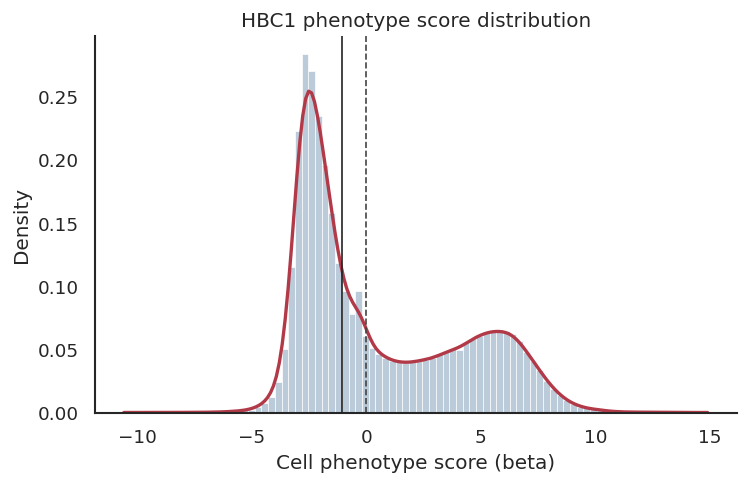

,value
count,126438.000000
mean,0.530528
std,3.590246
min,-9.561362
1%,-3.963846
5%,-3.213167
25%,-2.397176
50%,-1.052434
75%,3.680885
95%,7.100601


In [6]:
dist_result = plot_beta_distribution(
    BETA_PATH,
    OUTPUT_DIR / 'hbc1_beta_distribution.pdf',
    show=True,
)

dist_result['summary']

In [7]:
dist_result['peaks']

,beta,density
0,-2.676169,0.283307
1,-0.332273,0.095776
2,6.113440,0.064814


## 3. Spatial visualization

The spatial map overlays the beta score on the H&E image by recovering cell centroids from the nuclei segmentation mask. Red cells have higher phenotype-associated beta scores and blue cells have lower scores.

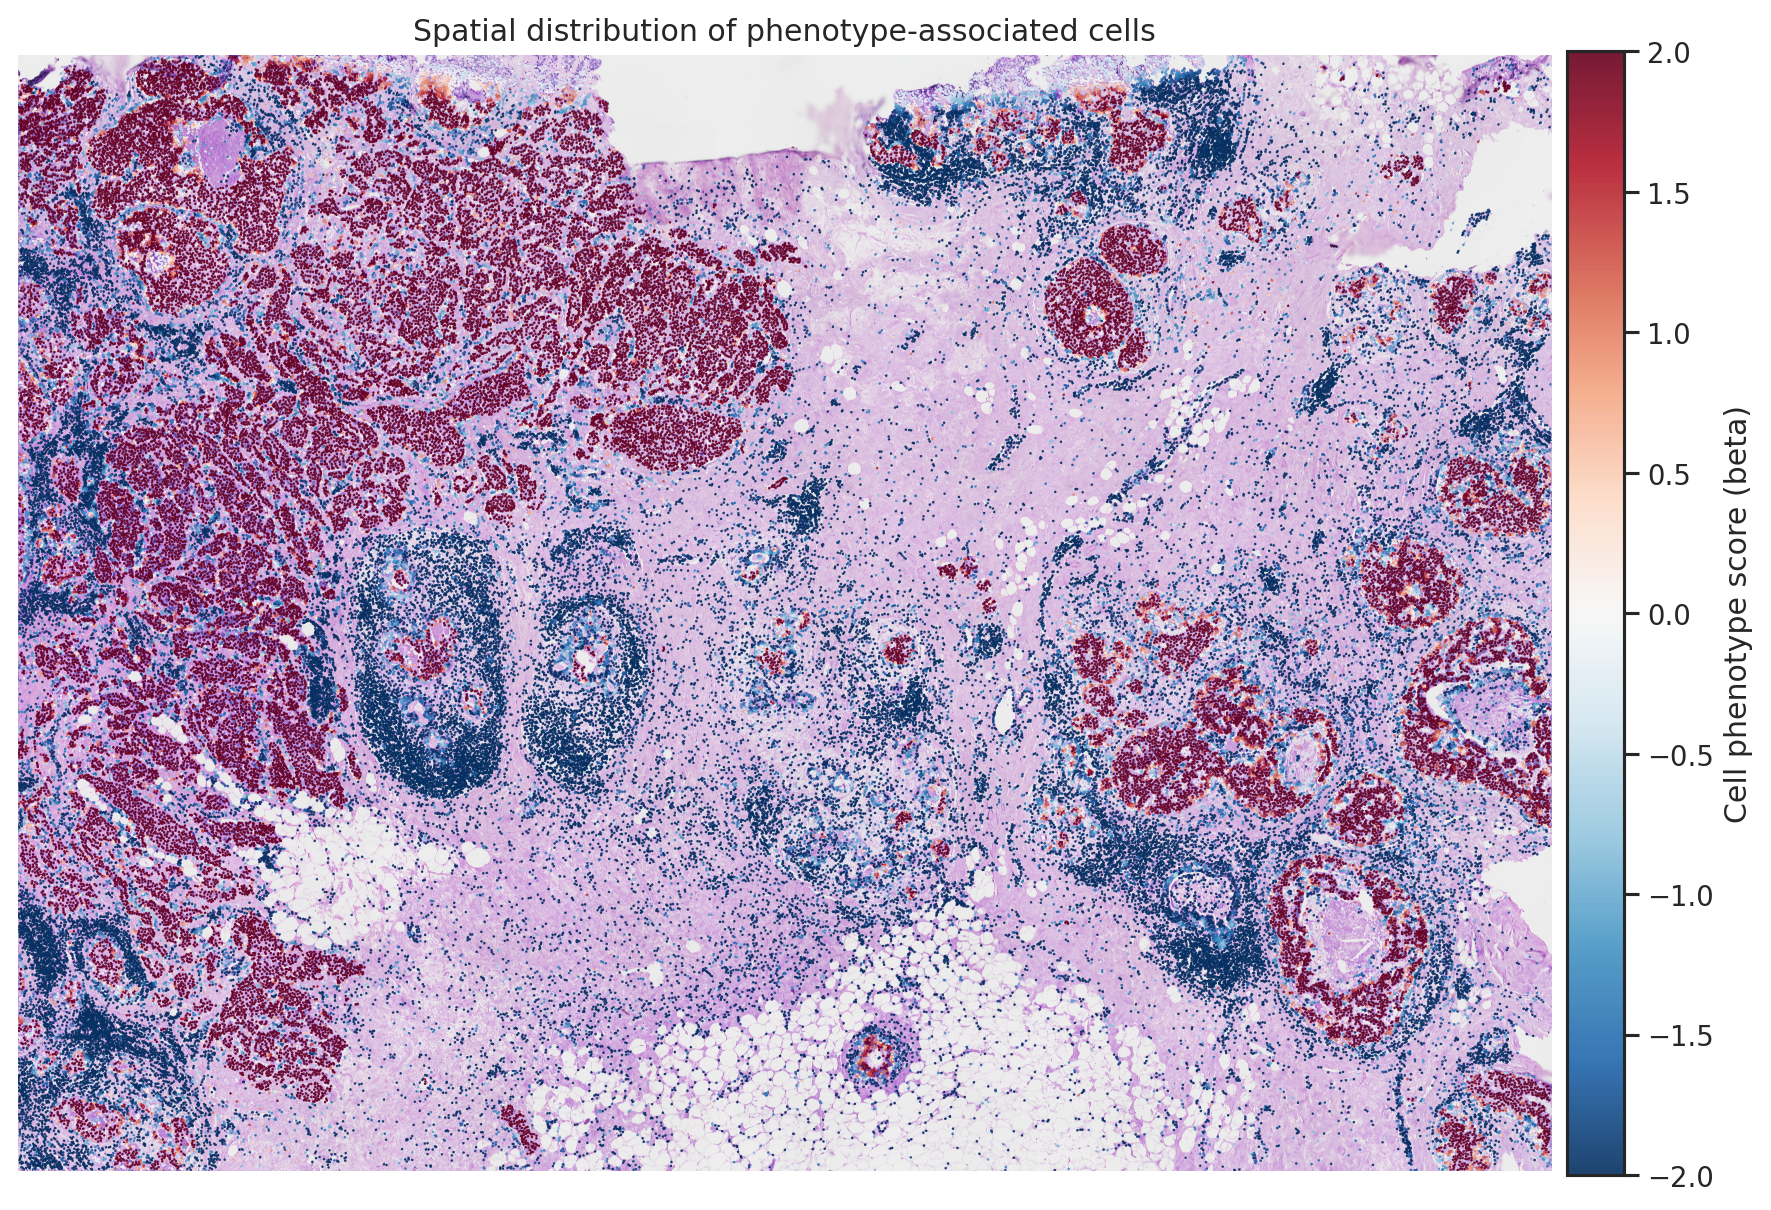

{'path': 'hbc1_phenotype_norm.pdf',
 'n_cells': 125766,
 'score_range': (-2.0, 2.0)}

In [8]:
spatial_result = plot_spatial_phenotype_scores(
    beta_path=BETA_PATH,
    mask_path=MASK_PATH,
    he_image_path=HE_IMAGE_PATH,
    annotation_csv=ANNOTATION_PATH,
    output_path=OUTPUT_DIR / 'hbc1_phenotype_norm.pdf',
    clip_abs=2.0,
    point_size=1.0,
    show=True,
)

{**spatial_result, "path": Path(spatial_result["path"]).name}

## 4. Cell-type to risk-stratum flow

The Sankey plot summarizes how annotated cell classes distribute across beta-score quintiles. This reproduces the alluvial-style impact plot used in the original HBC1 analysis.

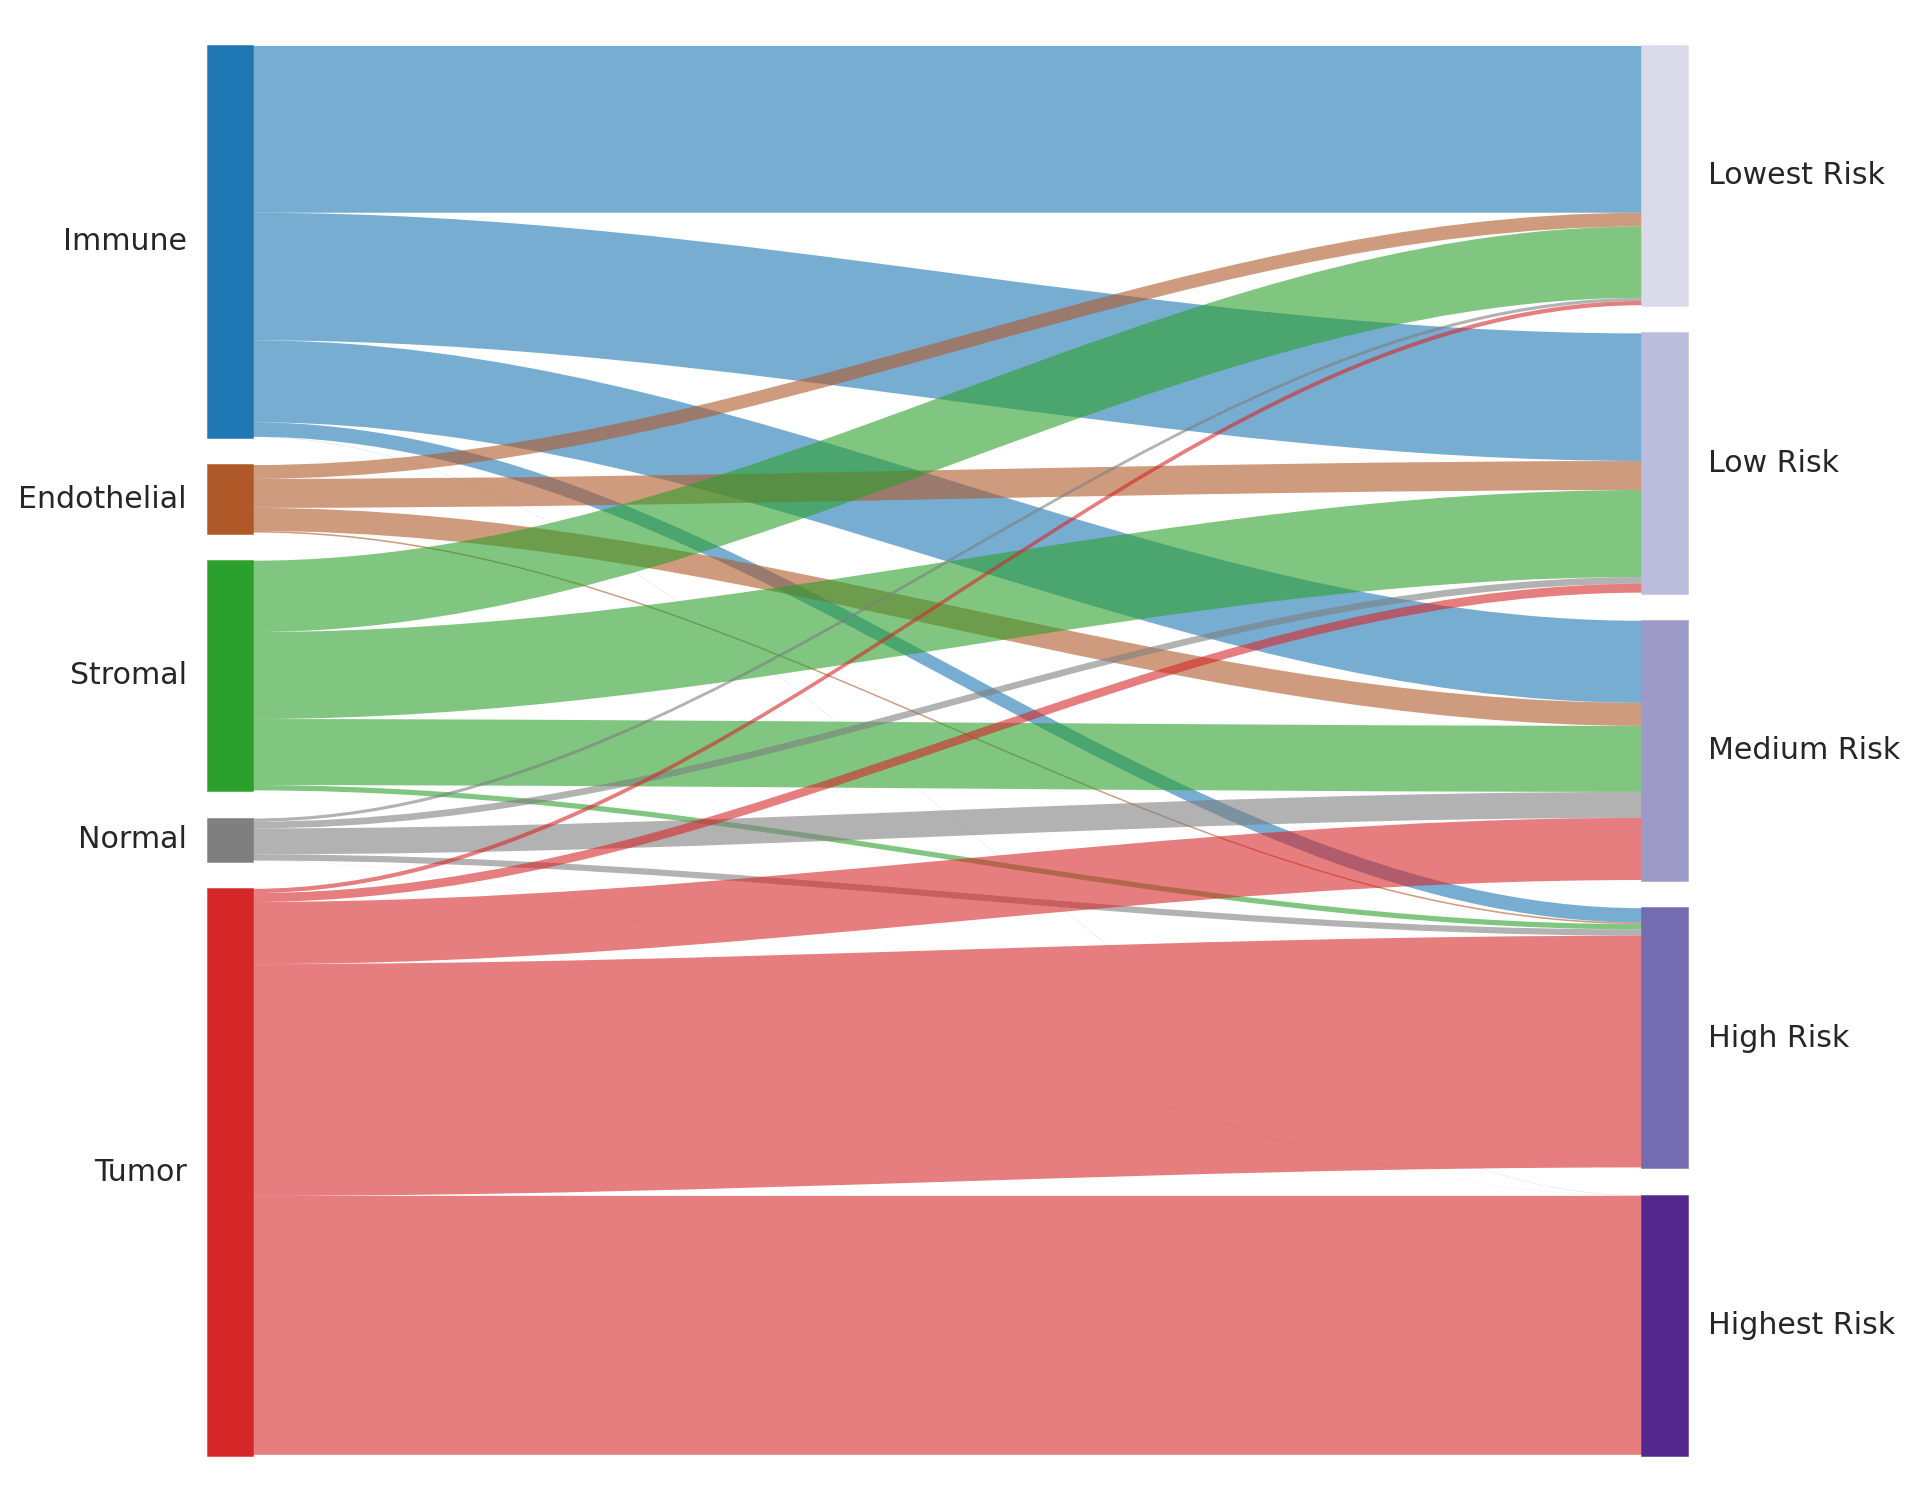

Cells shown: 125,766


In [9]:
merge_map = {
    "Cancer_epithelial": "Tumor", "T_cells": "Immune",
    "B_cells": "Immune", "Myeloid": "Immune",
    "Stromal": "Stromal", "Endothelial": "Endothelial",
    "Normal_epithelial": "Normal",
}
celltype_colors = {
    "Immune": "#1F77B4", "Endothelial": "#B05928",
    "Stromal": "#2CA02C", "Normal": "#7F7F7F",
    "Tumor": "#D62728",
}
risk_colors = {
    "Lowest Risk": "#DADAEB",
    "Low Risk": "#BCBDDC", "Medium Risk": "#9E9AC8",
    "High Risk": "#756BB1", "Highest Risk": "#54278F",
}

beta = pd.read_parquet(BETA_PATH)
if "beta" not in beta.columns and beta.shape[1] == 1:
    beta = beta.rename(columns={beta.columns[0]: "beta"})
beta.index = beta.index.astype(str)
beta["beta"] = pd.to_numeric(beta["beta"], errors="coerce")
beta = beta.dropna(subset=["beta"])
annotation = pd.read_csv(ANNOTATION_PATH, index_col=0)
annotation.index = annotation.index.astype(str)
annotation["CellType"] = annotation["Ensemble_Label"].map(merge_map)
combined = beta.join(annotation[["CellType"]].dropna(), how="inner")

left_nodes = [n for n in ["Immune", "Endothelial", "Stromal", "Normal", "Tumor"] if n in combined["CellType"].unique()]
risk_nodes = ["Lowest Risk", "Low Risk", "Medium Risk", "High Risk", "Highest Risk"]
combined["RiskStrata"] = pd.qcut(combined["beta"], q=5, labels=risk_nodes, duplicates="drop")
risk_nodes = [str(x) for x in combined["RiskStrata"].cat.categories]
flow = combined.groupby(["CellType", "RiskStrata"], observed=True).size().reset_index(name="value")

total = flow["value"].sum()
gap = 0.02
available_height = 1 - gap * (max(len(left_nodes), len(risk_nodes)) - 1)
scale = available_height / total

def node_spans(nodes, column):
    totals = flow.groupby(column, observed=True)["value"].sum()
    spans = {}
    top = 1.0
    for node in nodes:
        height = totals[node] * scale
        spans[node] = [top - height, top]
        top -= height + gap
    return spans

left_spans = node_spans(left_nodes, "CellType")
right_spans = node_spans(risk_nodes, "RiskStrata")
left_cursor = {node: span[1] for node, span in left_spans.items()}
right_cursor = {node: span[1] for node, span in right_spans.items()}

fig, ax = plt.subplots(figsize=(11, 8.5))
x_left, x_right, node_width = 0.08, 0.89, 0.025
for left in left_nodes:
    for right in risk_nodes:
        value = int(flow.loc[(flow["CellType"] == left) & (flow["RiskStrata"].astype(str) == right), "value"].sum())
        if value == 0:
            continue
        height = value * scale
        y0_top, y0_bottom = left_cursor[left], left_cursor[left] - height
        y1_top, y1_bottom = right_cursor[right], right_cursor[right] - height
        left_cursor[left], right_cursor[right] = y0_bottom, y1_bottom
        vertices = [
            (x_left + node_width, y0_top),
            (0.38, y0_top), (0.62, y1_top), (x_right, y1_top),
            (x_right, y1_bottom),
            (0.62, y1_bottom), (0.38, y0_bottom), (x_left + node_width, y0_bottom),
            (x_left + node_width, y0_top),
        ]
        codes = [MplPath.MOVETO] + [MplPath.CURVE4] * 3 + [MplPath.LINETO] + [MplPath.CURVE4] * 3 + [MplPath.CLOSEPOLY]
        ax.add_patch(PathPatch(MplPath(vertices, codes), facecolor=celltype_colors[left], edgecolor="none", alpha=0.60))

for node, (bottom, top) in left_spans.items():
    ax.add_patch(Rectangle((x_left, bottom), node_width, top - bottom, color=celltype_colors[node]))
    ax.text(x_left - 0.012, (bottom + top) / 2, node, ha="right", va="center")
for node, (bottom, top) in right_spans.items():
    ax.add_patch(Rectangle((x_right, bottom), node_width, top - bottom, color=risk_colors[node]))
    ax.text(x_right + node_width + 0.012, (bottom + top) / 2, node, ha="left", va="center")

ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.02)
ax.axis("off")
fig.tight_layout()
sankey_path = OUTPUT_DIR / "hbc1_celltype_risk_sankey.png"
fig.savefig(sankey_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.close(fig)
display(Image(filename=sankey_path))
sankey_result = {"path": sankey_path, "n_cells": int(len(combined)), "flow": flow}
print(f"Cells shown: {sankey_result['n_cells']:,}")

In [10]:
sankey_result['flow'].head(10).style.hide(axis="index")

CellType,RiskStrata,value
Endothelial,Lowest Risk,1335
Endothelial,Low Risk,2819
Endothelial,Medium Risk,2235
Endothelial,High Risk,155
Endothelial,Highest Risk,2
Immune,Lowest Risk,16180
Immune,Low Risk,12381
Immune,Medium Risk,7957
Immune,High Risk,1399
Immune,Highest Risk,16


## Main outputs

- `beta_best.parquet`: cell-level phenotype beta scores from Step 2.
- `hbc1_beta_distribution.pdf`: beta score distribution with density peaks.
- `hbc1_phenotype_norm.pdf`: spatial phenotype score overlay, comparable to the reference `phenotype_norm.pdf`.
- `hbc1_celltype_risk_sankey.png`: cell-type to risk-stratum flow plot.